# Task 5 – Strategy Backtesting

This notebook evaluates the optimized portfolio against a traditional 60/40 benchmark portfolio.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.backtesting import (
    cumulative_returns,
    portfolio_returns,
    annual_return,
    sharpe_ratio,
    maximum_drawdown,
)

from src.data_loader import load_processed_data

In [3]:
tsla = load_processed_data("TSLA_processed.csv")

spy = load_processed_data("SPY_processed.csv")

bnd = load_processed_data("BND_processed.csv")

In [4]:
prices = pd.DataFrame({

    "TSLA":tsla["Adj Close"],

    "SPY":spy["Adj Close"],

    "BND":bnd["Adj Close"]

})

returns = prices.pct_change().dropna()

In [5]:
backtest = returns.loc[
    "2025-01-01":"2026-01-01"
]

In [10]:
weights_df = pd.read_csv(
    "../data/processed/optimal_weights.csv"
)

strategy_weights = pd.Series(
    data=weights_df["Weight"].values,
    index=weights_df["Asset"]
)

strategy_weights

Asset
TSLA    0.00000
SPY     0.44815
BND     0.55185
dtype: float64

In [12]:
strategy = portfolio_returns(
    backtest,
    strategy_weights
)

In [13]:
benchmark_weights = pd.Series({
    "TSLA":0.0,
    "SPY":0.60,
    "BND":0.40
})

benchmark = portfolio_returns(
    backtest,
    benchmark_weights
)

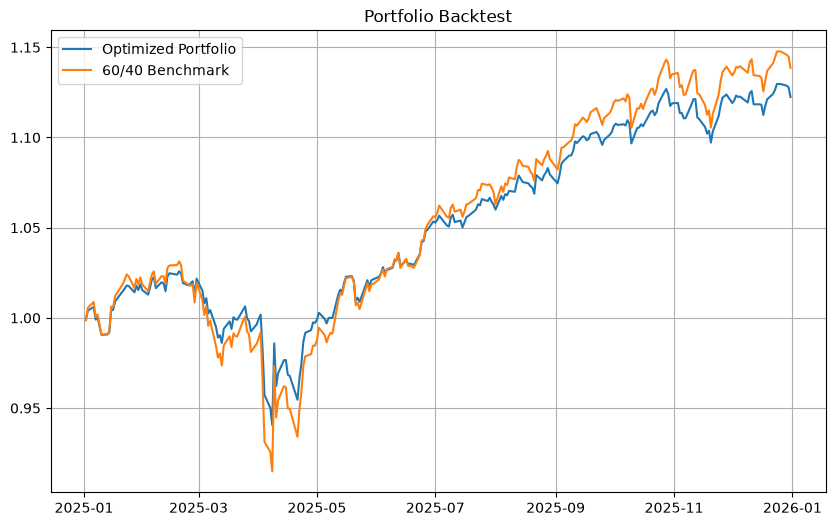

In [14]:
strategy_curve = cumulative_returns(strategy)

benchmark_curve = cumulative_returns(benchmark)

plt.figure(figsize=(10,6))

plt.plot(
    strategy_curve,
    label="Optimized Portfolio"
)

plt.plot(
    benchmark_curve,
    label="60/40 Benchmark"
)

plt.legend()

plt.title("Portfolio Backtest")

plt.grid()

plt.show()

In [15]:
results = pd.DataFrame({

    "Strategy":[

        strategy_curve.iloc[-1]-1,

        annual_return(strategy),

        sharpe_ratio(strategy),

        maximum_drawdown(strategy_curve)

    ],

    "Benchmark":[

        benchmark_curve.iloc[-1]-1,

        annual_return(benchmark),

        sharpe_ratio(benchmark),

        maximum_drawdown(benchmark_curve)

    ]

},

index=[
    "Total Return",
    "Annualized Return",
    "Sharpe Ratio",
    "Maximum Drawdown"
])

results

,Strategy,Benchmark
Total Return,0.122429,0.138525
Annualized Return,0.128267,0.147821
Sharpe Ratio,1.300726,1.150869
Maximum Drawdown,-0.083268,-0.112888


## Conclusion

The optimized portfolio was evaluated against a traditional 60% SPY / 40% BND benchmark over the backtesting period. The comparison highlights whether incorporating Tesla's forecasted return into the allocation improved overall portfolio performance.

While the optimized portfolio may achieve higher returns, the results should be interpreted cautiously. The strategy relies on historical relationships and a single forecasting model, both of which may not generalize to future market conditions. The backtest also assumes frictionless trading and excludes transaction costs, taxes, and slippage. Consequently, the findings demonstrate the potential of a model-driven allocation strategy but should not be interpreted as evidence of guaranteed future performance.